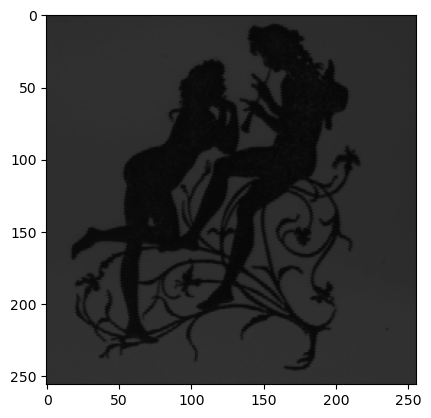

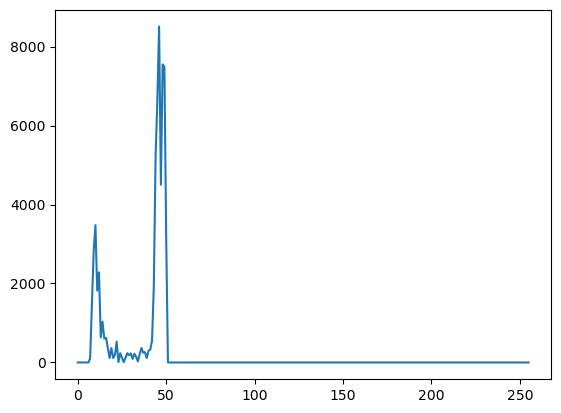

In [64]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image = cv2.imread("images/AMOUR.png", cv2.IMREAD_GRAYSCALE)

# Visualizar imagen
plt.imshow(image, cmap="gray",  vmin=0, vmax=255)
plt.show()

# Visualizar histograma (MUSCLE)
hist = cv2.calcHist([image],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

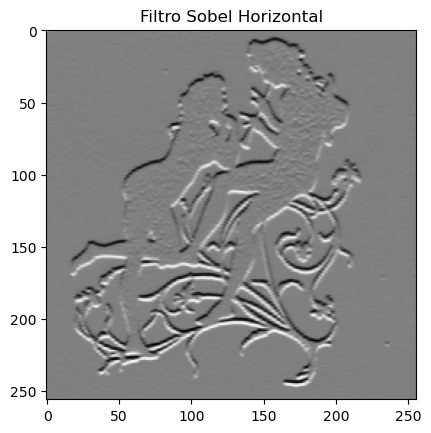

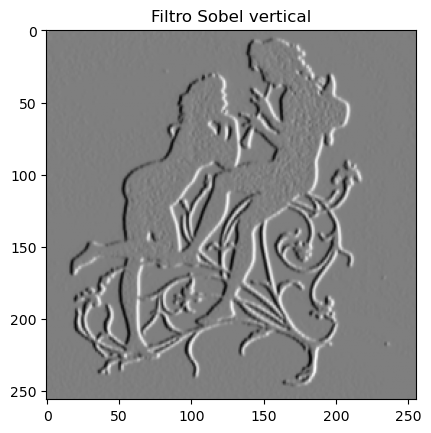

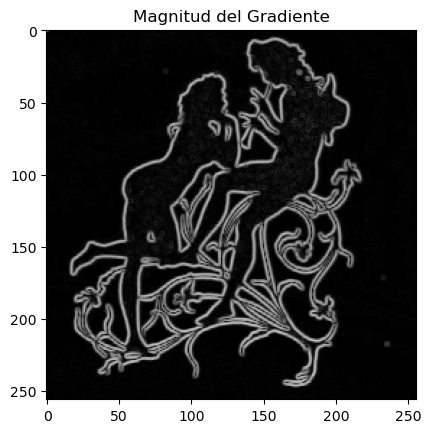

In [65]:
# Contorno de objetos
from skimage.filters import sobel_h, sobel_v, sobel

#Aplica el filtro Sobel horizontal
img_sh = sobel_h(image)
# Visualizar imagen
plt.imshow(img_sh, cmap="gray")
plt.title("Filtro Sobel Horizontal")
plt.show()

#--- Aplique un filtro de Sobel vertical sobre la imagen (que corresponde al cálculo del gradiente de la imagen en la dirección X ). Visualice los resultados.
#Aplica el filtro Sobel vertical
img_sv = sobel_v(image)
# Visualizar imagen
plt.imshow(img_sv, cmap="gray")
plt.title("Filtro Sobel vertical")
plt.show()

# Calcule la norma (magnitud) del gradiente de acuerdo con la definición a partir de las dos imágenes resultantes anteriores. Visualice los resultados.
# Magnitud del gradiente
gradiente_sobel = np.sqrt(img_sh**2 + img_sv**2)

# Visualizar
plt.imshow(gradiente_sobel, cmap="gray")
plt.title("Magnitud del Gradiente")
plt.show()



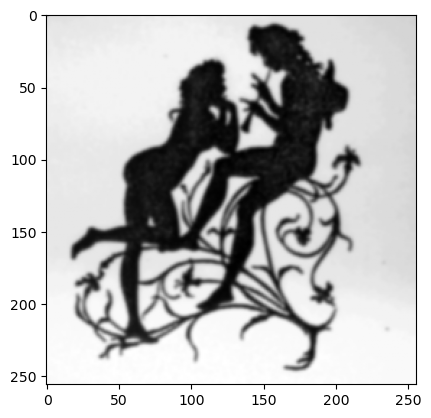

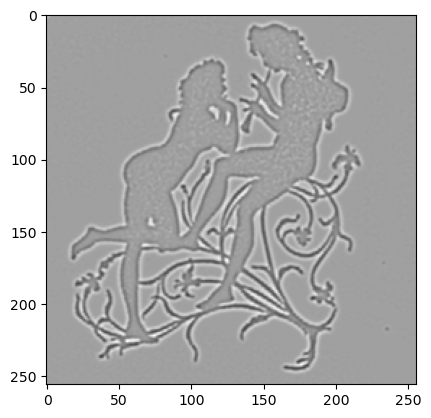

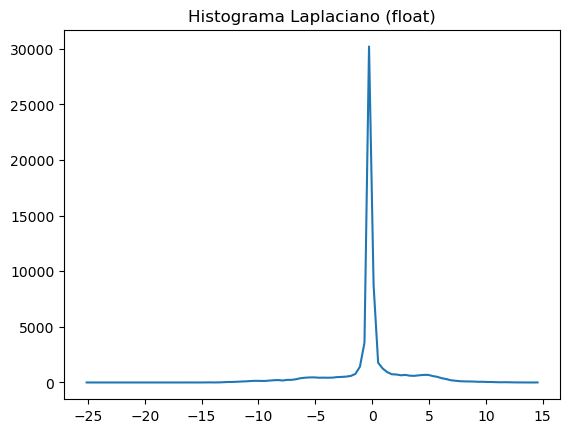

uint8
float64
float64


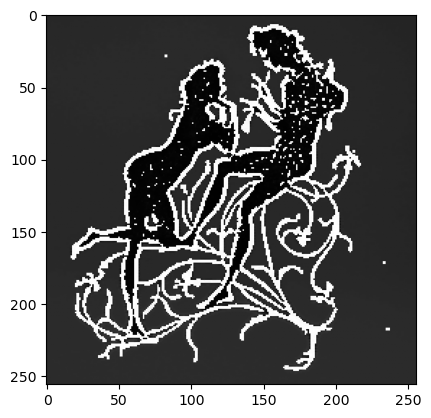

In [74]:
from skimage.filters import gaussian
from skimage.filters import laplace

img_gaus = gaussian(image, sigma=1, preserve_range=True)

# Visualizar imagen
plt.imshow(img_gaus, cmap="gray")
plt.show()

img_l = laplace(img_gaus, ksize=3)

# Visualizar imagen
plt.imshow(img_l, cmap="gray")
plt.show()

# Visualizar histograma
hist, bins = np.histogram(img_l.flatten(), bins=100)

plt.plot(bins[:-1], hist)
plt.title("Histograma Laplaciano (float)")
plt.show()

print(image.dtype)
print(img_l.dtype)
print(gradiente_sobel.dtype)
img_l = img_l.astype(np.uint8)
# Imagen final
final_image = cv2.bitwise_or(image, img_l,0)

# Visualizar imagen final
plt.imshow(final_image, cmap="gray")
plt.show()